---
title: Linear Regression

---

::: {.callout-tip}
## Slides
[Slides](https://docs.google.com/presentation/d/19xKdVzZoa0kbkkm8uI9Hp_NWHs4Nfw8Pg-5ONJf0c0Y/edit?slide=id.p#slide=id.p)
::: 



## Supervised Learning overview 

$$
\mathbf{y} = \mathbf{f}[\mathbf{x}]. \tag{1}
$$

$$
\mathbf{y} = \mathbf{f}[\mathbf{x}, \boldsymbol{\phi}].
$$

$$
\hat{\boldsymbol{\phi}}
=
\operatorname*{arg\,min}_{\boldsymbol{\phi}}
L[\boldsymbol{\phi}].
$$


<img src="assets/Chap02/SupervisedLinear.svg" style="filter: invert(1);" align="right" width="50%" border="0px">

Linear regression model. For a given choice of parameters ϕ= [ϕ0,ϕ1], the model makes a prediction for the out-
put (y-axis) based on the input (x-axis).

Different choices for the y-intercept ϕ0 and the slope ϕ1 change these predictions (cyan, orange, and gray lines). The linear regression model (equation 2.4) defines a family of input/output relations (lines) and the parameters determine the member of the family (the particular line). (Interactive figure)

## Linear regression example 

### 1D linear regression model

$$
\begin{aligned}
y
&= f[x,\boldsymbol{\phi}] \\
&= \phi_0+\phi_1x.
\end{aligned}
\tag{1}
$$

In [ ]:
# Define 1D linear regression model
def f(x, phi0, phi1):
  
  y = phi0 + x * phi1

  return y 

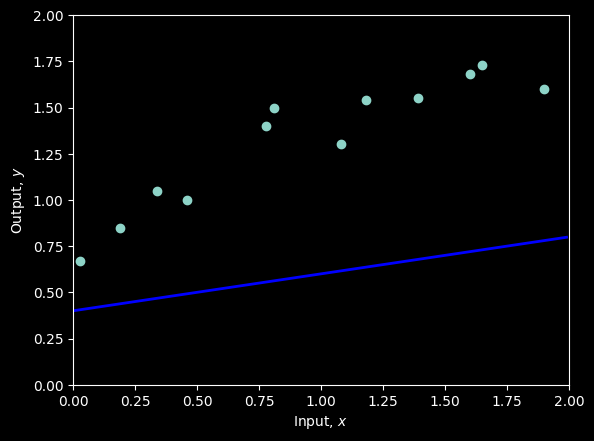

In [11]:
# Math library
import numpy as np
# Plotting library
import matplotlib.pyplot as plt

# Set style to dark mode 
plt.style.use('dark_background')


# Create some input / output data
x = np.array([0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.60, 1.65, 1.90])
y = np.array([0.67, 0.85, 1.05, 1.0, 1.40, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6 ])

# Function to help plot the data
def plot(x, y, phi0, phi1):
    fig,ax = plt.subplots()
    ax.scatter(x,y)
    plt.xlim([0,2.0])
    plt.ylim([0,2.0])
    ax.set_xlabel('Input, $x$')
    ax.set_ylabel('Output, $y$')
    # Draw line
    x_line = np.arange(0,2,0.01)
    y_line = f(x_line, phi0, phi1)
    plt.plot(x_line, y_line,'b-',lw=2)

    plt.show()

# Set the intercept and slope as in figure 2.2b
phi0 = 0.4 ; phi1 = 0.2
# Plot the data and the model
plot(x,y,phi0,phi1)


### Loss


$$
\begin{aligned}
L[\boldsymbol{\phi}]
&= \sum_{i=1}^{I}
\left(f[x_i,\boldsymbol{\phi}]-y_i\right)^2 \\
&= \sum_{i=1}^{I}
\left(\phi_0+\phi_1x_i-y_i\right)^2.
\end{aligned}
\tag{1}
$$


In [9]:
# Function to calculate the loss
def compute_loss(x,y,phi0,phi1):

  predictions = f(x, phi0, phi1)
  squared = (y - predictions)**2
  loss = sum(squared)

  return loss

# Compute the loss for our current model
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}')

Your Loss = 7.07


$$
\begin{aligned}
\hat{\boldsymbol{\phi}}
&= \operatorname*{arg\,min}_{\boldsymbol{\phi}}
L[\boldsymbol{\phi}] \\
&= \operatorname*{arg\,min}_{\boldsymbol{\phi}}
\left[
\sum_{i=1}^{I}
\left(
f[x_i,\boldsymbol{\phi}]-y_i
\right)^2
\right] \\
&= \operatorname*{arg\,min}_{\boldsymbol{\phi}}
\left[
\sum_{i=1}^{I}
\left(
\phi_0+\phi_1x_i-y_i
\right)^2
\right].
\end{aligned}
$$

<img src="assets/Chap02/SupervisedLinearFitError.svg" style="filter: invert(1);" width="100%">

Linear regression training data, model, and loss. a) The training data (orange points) consist of I = 12 input/output pairs {xi,yi}. b–d) Each panel shows the linear regression model with different parameters. Depending on the choice of y-intercept and slope parameters ϕ= [ϕ0,ϕ1], the model errors (orange dashed lines) may be larger or smaller. The loss L is the sum of the squares of these errors. The parameters that define the lines in panels (b) and (c) have large losses L= 7.07 and L= 10.28, respectively because the models fit badly.
The loss L= 0.20 in panel (d) is smaller because the model fits well; in fact, this has the smallest loss of all possible lines, so these are the optimal parameters.
(Interactive figure)

<img src="assets/Chap02/SupervisedSurface.svg" style="filter: invert(1);" width="100%">

Loss function for linear regression model with the dataset in figure 2.2a.
a) Each combination of parameters ϕ= [ϕ0,ϕ1] has an associated loss. The resulting loss function L[ϕ] can be visualized as a surface. The three circles represent
the lines from figure 2.2b–d. b) The loss can also be visualized as a heatmap, where brighter regions represent larger losses; here we are looking straight down
at the surface in (a) from above and gray ellipses represent isocontours. The best fitting line (figure 2.2d) has the parameters with the smallest loss (green circle).



### Training

<img src="assets/Chap02/SupervisedOpt.svg" style="filter: invert(1);" width="100%">

Linear regression training. The goal is to find the y-intercept and slope parameters that correspond to the smallest loss. a) Iterative training algorithms
initialize the parameters randomly and then improve them by “walking downhill” until no further improvement can be made. Here, we start at position 0 and move
a certain distance downhill (perpendicular to the contours) to position 1. Then we re-calculate the downhill direction and move to position 2. Eventually, we
reach the minimum of the function (position 4). b) Each position 0–4 from panel (a) corresponds to a different y-intercept and slope and so represents a different
line. As the loss decreases, the lines fit the data more closely. (Interactive figure)

### Testing

In [12]:

# Make a 2D grid of possible phi0 and phi1 values
phi0_mesh, phi1_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.02))

# Make a 2D array for the losses
all_losses = np.zeros_like(phi1_mesh)
# Run through each 2D combination of phi0, phi1 and compute loss
for indices,temp in np.ndenumerate(phi1_mesh):
    all_losses[indices] = compute_loss(x,y, phi0_mesh[indices], phi1_mesh[indices])

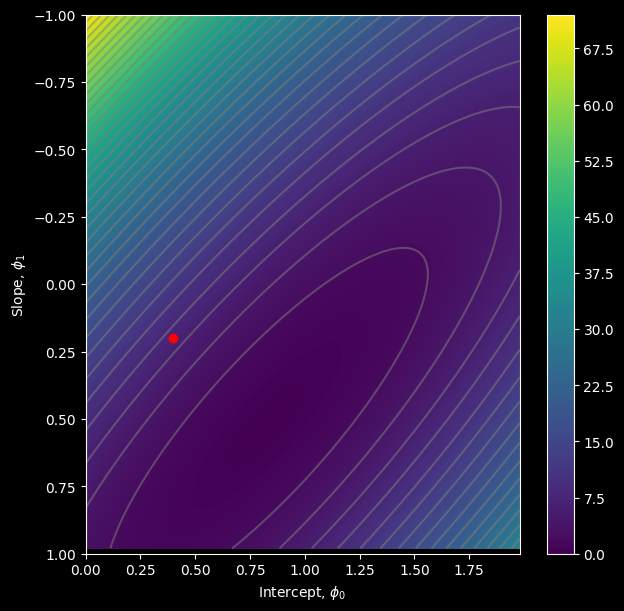

In [20]:
# Plot the loss function as a heatmap
fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7,7)
levels = 256
a = ax.contourf(phi0_mesh, phi1_mesh, all_losses ,levels)
levels = 40
# adding gray topology lines
ax.contour(phi0_mesh, phi1_mesh, all_losses ,levels, colors=['#80808080'])
ax.set_ylim([1,-1])
ax.set_xlabel(r'Intercept, $\phi_0$')
ax.set_ylabel(r'Slope, $\phi_1$')

# Plot the position of your best fitting line on the loss function
# It should be close to the minimum
ax.plot(phi0,phi1,'ro')

plt.colorbar(a)
plt.show()

## 2D Linear function

In [ ]:
# Code to draw 2D function -- read it so you know what is going on, but you don't have to change it
def draw_2D_function(x1_mesh, x2_mesh, y):
    fig, ax = plt.subplots()
    fig.set_size_inches(7,7)
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256 ,cmap = 'hot', vmin=-10,vmax=10.0)
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel('x1');ax.set_ylabel('x2')
    levels = np.arange(-10,10,1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')
    plt.show()

# Define a linear function with two inputs, x1 and x2
def linear_function_2D(x1,x2,beta,omega1,omega2):
  
  y = beta + x1*omega1 + x2*omega2

  return y

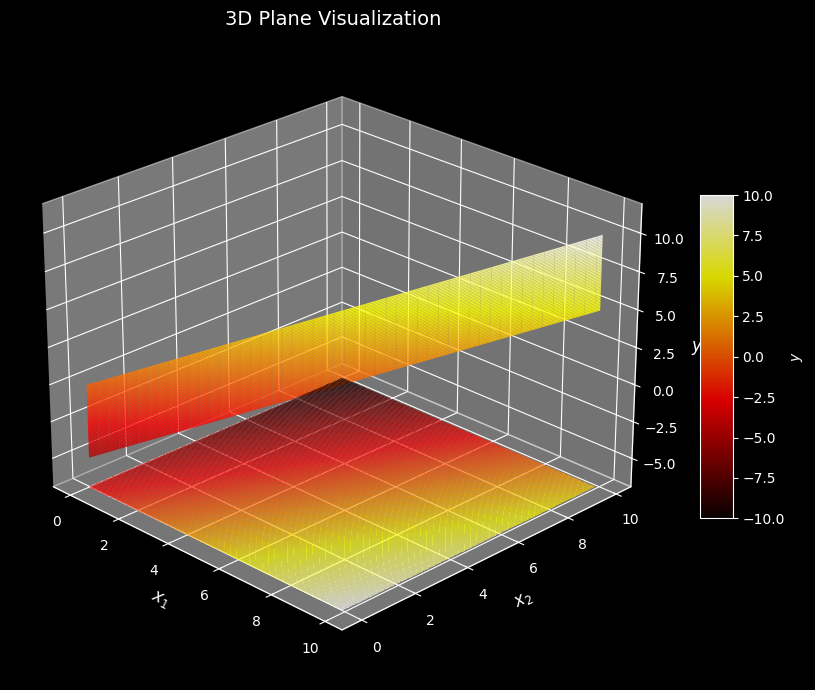

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def draw_3D_function(x1_mesh, x2_mesh, y):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the 3D surface plane
    surf = ax.plot_surface(
        x1_mesh, x2_mesh, y, 
        cmap='hot', 
        vmin=-10.0, vmax=10.0, 
        edgecolor='none', 
        alpha=0.85
    )
    
    # Add 2D contour projection onto the floor (z-min plane)
    z_min = np.min(y) - 2.0
    ax.contourf(x1_mesh, x2_mesh, y, levels=256, zdir='z', offset=z_min, cmap='hot', alpha=0.4)
    ax.set_zlim(z_min, np.max(y) + 2.0)
    
    # Labels
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_zlabel('$y$', fontsize=12)
    ax.set_title('3D Plane Visualization', fontsize=14)
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='$y$')
    
    # Set initial camera angle (elevation, azimuth)
    ax.view_init(elev=25, azim=-45)
    
    plt.tight_layout()
    plt.show()

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
# Example Usage:
draw_3D_function(x1, x2, y)


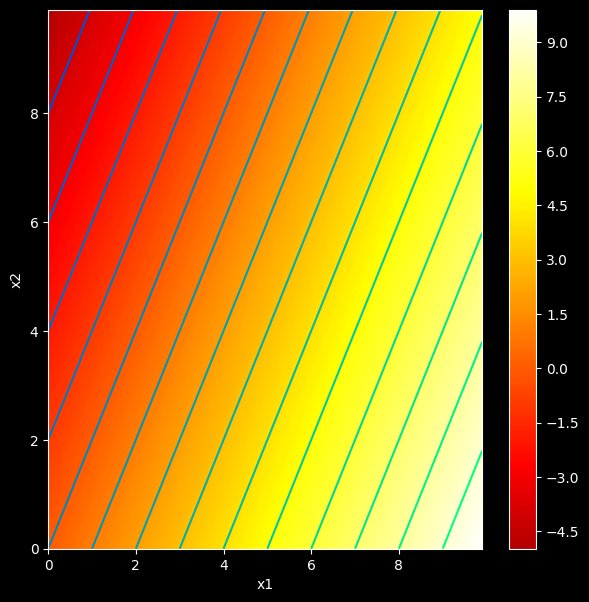

In [23]:
# Plot the 2D function

# Make 2D array of x and y points
x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# Compute the 2D function for given values of omega1, omega2
beta = 0.0; omega1 = 1.0; omega2 = -0.5
y  = linear_function_2D(x1,x2,beta, omega1, omega2)

# Draw the function.
# Color represents y value (brighter = higher value)
# Black = -10 or less, White = +10 or more
# 0 = mid orange
# Lines are contours where value is equal
draw_2D_function(x1,x2,y)

In [32]:
import plotly.graph_objects as go

def draw_3D_function_interactive(x1_mesh, x2_mesh, y):
    fig = go.Figure(data=[
        go.Surface(
            x=x1_mesh, 
            y=x2_mesh, 
            z=y, 
            colorscale='Hot',
            cmin=-10, 
            cmax=10
        )
    ])
    
    fig.update_layout(
        title='Interactive 3D Plane Visualization',
        scene=dict(
            xaxis_title='x1',
            yaxis_title='x2',
            zaxis_title='y'
        ),
        width=700,
        height=600
    )
    
    fig.show()

# Example Usage:
draw_3D_function_interactive(x1, x2, y)
